Import libraries

In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

Download Dataset

In [2]:
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'unemployment-in-india' dataset.
Dataset Path: /kaggle/input/unemployment-in-india


In [3]:
import os
print("Files:", os.listdir(path))

# Replace filename if different
file_name = os.listdir(path)[0]

Files: ['Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv']


Load Dataset

In [4]:
df = pd.read_csv(os.path.join(path, file_name))

print("\nFirst 5 rows")
print(df.head())


First 5 rows
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74 

Dataset Information

In [5]:
print("\nDataset Info")
print(df.info())

print("\nColumn Names")
print(df.columns)


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB
None

Column Names
Index(['Region', ' 

Clean Column Names

In [6]:
df.columns = df.columns.str.strip()

# Rename columns if needed
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


Missing Values

In [7]:
print("\nMissing Values")
print(df.isnull().sum())

# Remove missing rows
df = df.dropna()


Missing Values
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


Statistical Summary & Convert Date Column

In [ ]:

print("\nStatistics")
print(df.describe())

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

Average Unemployment by State

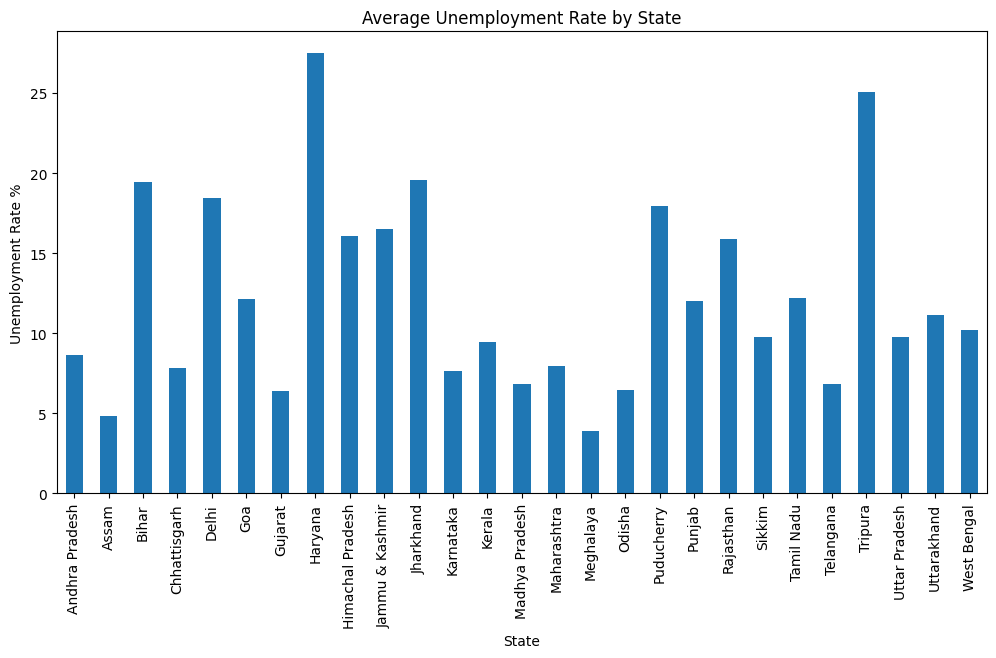

In [8]:
state_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(12,6))
state_avg.plot(kind="bar")
plt.title("Average Unemployment Rate by State")
plt.xlabel("State")
plt.ylabel("Unemployment Rate %")
plt.xticks(rotation=90)
plt.show()

Unemployment Trend Over Time

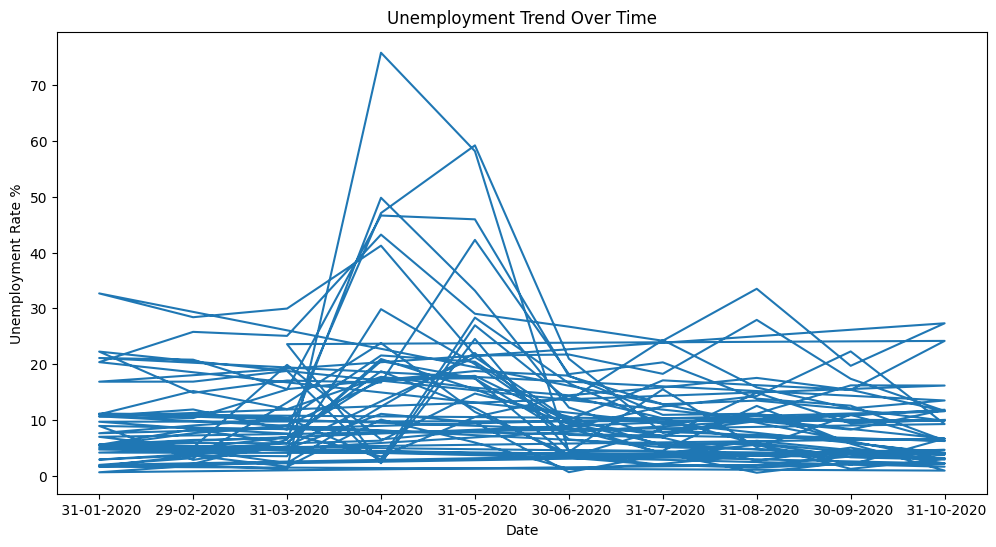

In [9]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Estimated Unemployment Rate (%)"])
plt.title("Unemployment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate %")
plt.show()

Urban vs Rural Analysis

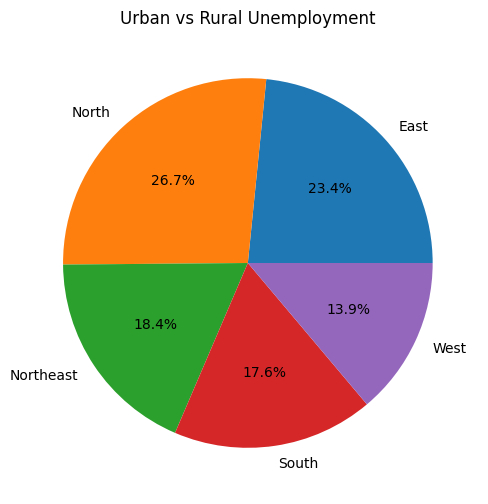

In [11]:
area_avg = df.groupby("Region.1")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(6,6))
area_avg.plot(kind="pie", autopct="%1.1f%%")
plt.title("Urban vs Rural Unemployment")
plt.ylabel("")
plt.show()

Top 10 Highest Unemployment States

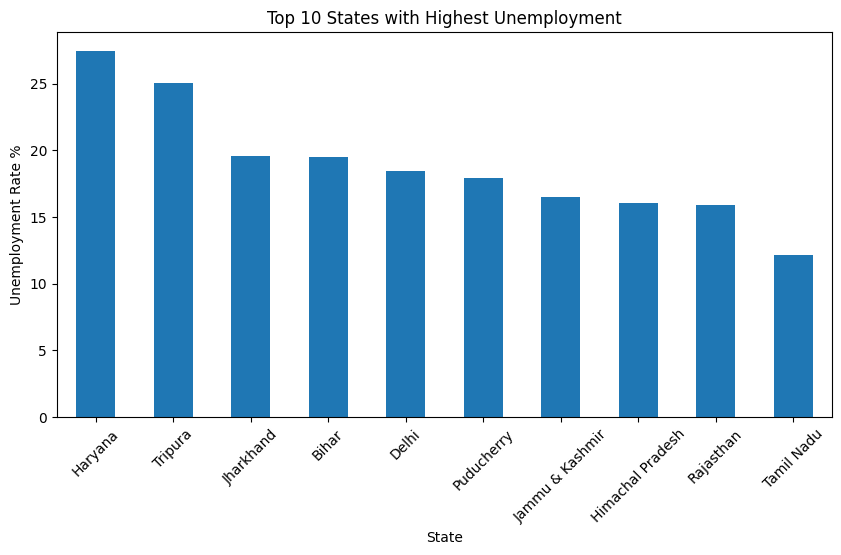

In [12]:
top_states = state_avg.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar")
plt.title("Top 10 States with Highest Unemployment")
plt.xlabel("State")
plt.ylabel("Unemployment Rate %")
plt.xticks(rotation=45)
plt.show()

 Correlation Analysis


In [13]:

print("\nCorrelation Matrix")
print(df.corr(numeric_only=True))


Correlation Matrix
                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.245176   
Estimated Labour Participation Rate (%)                        -0.073540   
longitude                                                       0.149976   
latitude                                                       -0.023976   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.245176   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)           -0.047948   
longitude                                         -0.113664   
latitude                                          -0.119321   

                                         Estimated Labour Participation Rate (%)  \
Estimated Unemployment Rate (%)                             